# Social Network: Scientific Analysis on the Epstein Files

#### Objectives of the project:
- To apply Natural Language Processing (NLP) and Network Science to the 3-million-page DOJ document dump to identify key hubs and gatekeepers within the social web.

#### Project Roadmap
- Extraction: Use spaCy to perform Named Entity Recognition (NER) to find names of people and organizations.
- Cleaning & Deduplication: Use rapidfuzz to normalize names (e.g., merging "Bill Clinton" and "William Clinton").
- Graph Construction: Infer connections based on document co-occurrence.
- Analysis: Calculate centrality measures to find the most influential nodes.

#### Tools Used
- NLP: spaCy (en_core_web_md)
- Data Manipulation: Pandas
- Entity Matching: RapidFuzz
- Graphing: NetworkX & Matplotlib

In [1]:
import spacy
import pandas as pd
from rapidfuzz import fuzz, process 


nlp = spacy.load("en_core_web_md") # en_core_web_md is a medium-sized English model that includes word vectors and is suitable for various NLP tasks.

In [2]:
text = "Donald Trump and Bill Clinton were seen boarding the Lolita Express at Teterboro Airport in New Jersey."

doc = nlp(text) # this is where the text is processed and stored in an OOP manner

for ent in doc.ents: # we loop through the entities found in the doc
    print(ent.text, "--", ent.label_) # this will print the entity text and its label

Donald Trump -- PERSON
Bill Clinton -- PERSON
the Lolita Express -- ORG
Teterboro Airport -- FAC
New Jersey -- GPE


In [3]:
result =[]

for ent in doc.ents:
    temp = [ent.text, ent.label_]
    result.append(temp)

df = pd.DataFrame(result, columns=['Entity', 'Type'])

df.head()


,Entity,Type
0,Donald Trump,PERSON
1,Bill Clinton,PERSON
2,the Lolita Express,ORG
3,Teterboro Airport,FAC
4,New Jersey,GPE


In [4]:
df = df.assign(Normalized_Entity=df['Entity'].str.lower()) # we create a new column with the entity text in lowercase for better matching

df.Normalized_Entity.nunique()

df

,Entity,Type,Normalized_Entity
0,Donald Trump,PERSON,donald trump
1,Bill Clinton,PERSON,bill clinton
2,the Lolita Express,ORG,the lolita express
3,Teterboro Airport,FAC,teterboro airport
4,New Jersey,GPE,new jersey


In [5]:
unique_names = df['Normalized_Entity'].unique().tolist() # we get the unique normalized entity names as a list

query = 'trump ' # this is the name we want to match

matches = process.extract(query, unique_names, limit=3, scorer=fuzz.partial_ratio) # we use rapidfuzz's process.extract to find the best matches for the query in the unique names, using partial_ratio as the scoring function

print(f"Matches for '{query}': {matches}") # this will print the matches and their scores

Matches for 'trump ': [('donald trump', 90.9090909090909, 0), ('the lolita express', 40.0, 2), ('teterboro airport', 36.36363636363637, 3)]


## Initialization of the Social Web

In [6]:
# A fake "page" from the files
document_text = """
Ghislaine Maxwell was seen with Jeffrey Epstein at the palm beach residence. 
Also present was Donald Trump, who arrived later that evening.
"""

# 1. Process the text with your 'nlp' object
doc = nlp(document_text)

# 2. Extract only the PERSON names into a list
# Hint: Use a list comprehension to get [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
page_entities = [ent.text.lower().strip() for ent in doc.ents if ent.label_ == 'PERSON']

print(f"Entities on this page: {page_entities}")

Entities on this page: ['ghislaine maxwell', 'jeffrey epstein', 'donald trump']


In [8]:
import pytesseract
from pdf2image import convert_from_path
import os

# Let's target one flight log first
pdf_path = './data/B. Flight Log_Released in U.S. v. Maxwell_0_0_0_0.pdf'

def pdf_to_text(path):
    # Convert PDF pages to images
    pages = convert_from_path(path, 300) # 300 DPI for accuracy
    text_data = ""
    for page in pages:
        # Use Tesseract to read the image
        text_data += pytesseract.image_to_string(page)
    return text_data

# Test on one file
sample_text = pdf_to_text(pdf_path)
print(sample_text[:500]) # Print first 500 characters

*Publicly
released in
U.S. v. Maxwell

REMARKS. PROCEOU

IRCRAFT MAKE

3e 3 a ce Ps? hs
ee Pere er
iia Se

i
zi i
aes

Y
as a ca

a AlpcRart C. ORY
stl | FRE

ee
nee teres Ta :

=

cmy -— oN

<a co

VERB - Sev PLAre To

el x \rusnnwn + Revs \
25° PLane

sf | low Taw 1
2 i Ca
a ee

Toe - Dye-ltT LS

—“;GSeRenV yar Gypsies BUA CAA Gad

Te Le ton Crrsine. Myo PS pop full Uae?
a) Jute? Guy ys ue: Deis Croce:

aL
Z 2

| certify that the statements made by meon this form are true.

' ivy |
PILOT'S SIG


## Multiprocessing OCR data

In [9]:
from concurrent.futures import ProcessPoolExecutor
from pdf2image import convert_from_path
import pytesseract

def process_page(page):
    return pytesseract.image_to_string(page)

def fast_pdf_to_text(path):
    # 1. Convert all pages to images first
    print("Converting PDF to images...")
    pages = convert_from_path(path, 200) # Dropping to 200 DPI can double the speed
    
    # 2. Use all CPU cores to OCR the pages in parallel
    print(f"Starting OCR on {len(pages)} pages using all CPU cores...")
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_page, pages))
    
    return "".join(results)

In [10]:
import os

data_path = './data'
all_files = []

# This 'walks' through every subfolder for you
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.lower().endswith(('.pdf', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            all_files.append(full_path)

print(f"Found {len(all_files)} total files to process.")
# Let's look at the first 5 to verify
for f in all_files[:5]:
    print(f"Target: {f}")

Found 22935 total files to process.
Target: ./data/B. Flight Log_Released in U.S. v. Maxwell_Part3_0_0_0_0.pdf
Target: ./data/Jeffrey Epstein Part 07 of 08.pdf
Target: ./data/B. Flight Log_Released in U.S. v. Maxwell_Part5_0.pdf
Target: ./data/Jeffrey Epstein Part 18 of 18.PDF
Target: ./data/A. Evidence List_0_0_0_0.pdf


In [12]:
import os
import pytesseract
from pdf2image import convert_from_path
from concurrent.futures import ThreadPoolExecutor # Changed from Process to Thread

DATA_PATH = './data'
OUTPUT_PATH = './output'
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

def ocr_page(page):
    return pytesseract.image_to_string(page)

def process_document(file_path):
    try:
        if file_path.lower().endswith('.pdf'):
            # Convert PDF to images
            pages = convert_from_path(file_path, 200)
            # Use threads to handle OCR pages in parallel
            with ThreadPoolExecutor(max_workers=4) as executor:
                results = list(executor.map(ocr_page, pages))
            return "\n".join(results)
        else:
            return pytesseract.image_to_string(file_path)
    except Exception as e:
        return f"ERROR: {str(e)}"

# Get all files recursively
all_files = []
for root, _, files in os.walk(DATA_PATH):
    for file in files:
        if file.lower().endswith(('.pdf', '.jpg', '.jpeg')):
            all_files.append(os.path.join(root, file))

print(f"Starting resilient processing for {len(all_files)} files...")

for i, file_path in enumerate(all_files):
    # Use the filename and the immediate parent folder name to create a unique ID
    parent_folder = os.path.basename(os.path.dirname(file_path))
    file_name = os.path.basename(file_path)
    file_id = f"{parent_folder}_{file_name}".replace(' ', '_') + ".txt"
    save_path = os.path.join(OUTPUT_PATH, file_id)

    if os.path.exists(save_path):
        continue

    print(f"[{i+1}/{len(all_files)}] Processing: {file_name}")
    text_content = process_document(file_path)
    
    with open(save_path, 'w', encoding='utf-8') as f:
        f.write(text_content)

Starting resilient processing for 22935 files...
[1/22935] Processing: B. Flight Log_Released in U.S. v. Maxwell_Part3_0_0_0_0.pdf
[2/22935] Processing: Jeffrey Epstein Part 07 of 08.pdf
[3/22935] Processing: B. Flight Log_Released in U.S. v. Maxwell_Part5_0.pdf
[4/22935] Processing: Jeffrey Epstein Part 18 of 18.PDF
[5/22935] Processing: A. Evidence List_0_0_0_0.pdf
[6/22935] Processing: Jeffrey Epstein Part 20 of 20.PDF
[7/22935] Processing: Jeffrey Epstein Part 01 of 08.pdf
[8/22935] Processing: Jeffrey Epstein Part 16 of 16.PDF
[9/22935] Processing: Jeffrey Epstein Part 10 of 10.pdf
[10/22935] Processing: Jeffrey Epstein Part 06 of 08.pdf
[11/22935] Processing: Jeffrey Epstein Part 19 of 19.pdf
[12/22935] Processing: B. Flight Log_Released in U.S. v. Maxwell_Part6_0.pdf
[13/22935] Processing: Jeffrey Epstein Part 11 of 12.pdf
[14/22935] Processing: Jeffrey Epstein Part 21 of 21.pdf
[15/22935] Processing: Jeffrey Epstein Part 17 of 17.PDF
[16/22935] Processing: B. Flight Log_Release

KeyboardInterrupt: 

In [16]:
import os
import spacy
import pandas as pd
from itertools import combinations
import networkx as nx
from rapidfuzz import process, fuzz

# Load NLP model
nlp = spacy.load("en_core_web_md")

def clean_entities(text):
    doc = nlp(text)
    # Filter for Person entities, remove short 'noise' (under 4 chars), and title case them
    names = [ent.text.title().strip() for ent in doc.ents if ent.label_ == "PERSON"]
    return list(set([n for n in names if len(n) > 4]))

output_dir = './output'
processed_data = []

# Only take the files that are ALREADY finished
finished_files = [f for f in os.listdir(output_dir) if f.endswith('.txt')]

print(f"Analyzing {len(finished_files)} files for names...")

for file in finished_files:
    with open(os.path.join(output_dir, file), 'r', encoding='utf-8') as f:
        text = f.read()
        names = clean_entities(text)
        if len(names) > 1: # We need at least 2 people to form a connection
            processed_data.append({"file": file, "names": names})

df_graph = pd.DataFrame(processed_data)
print(f"Found connections in {len(df_graph)} documents.")

Analyzing 931 files for names...
Found connections in 627 documents.


In [17]:
G = nx.Graph()

for names_list in df_graph['names']:
    # Create every possible pair from the names found in one document
    pairs = list(combinations(names_list, 2))
    for u, v in pairs:
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

print(f"Current Graph: {G.number_of_nodes()} People, {G.number_of_edges()} Connections.")

Current Graph: 4538 People, 425336 Connections.


In [ ]:
import re

# 1. Define a list of "Garbage" words to ignore
blacklist = ['Http', 'Https', 'Www', 'Released', 'Page', 'Evidence', 'Flight', 'Maxwell', 'Epstein', 'Apendix', 'Exhibit', 'Document', 'File', 'Report', 'Summary', 'Transcript', 'Email', 'Letter', 'Note', 'Memo']

def is_valid_name(name):
    # Regex to ensure it's mostly letters and spaces (no weird symbols or long URLs)
    if not re.match(r'^[a-zA-Z\s\.]+$', name):
        return False
    # Check against blacklist
    if any(word.lower() in name.lower() for word in blacklist):
        return False
    # Ignore names that are too short (OCR errors like 'A. B')
    if len(name) < 5:
        return False
    return True

# 2. Create a NEW clean graph
G_clean = nx.Graph()

for u, v, data in G.edges(data=True):
    if is_valid_name(u) and is_valid_name(v):
        # Only add connections that appear in more than 1 document (Weight > 1)
        if data['weight'] > 1:
            G_clean.add_edge(u, v, weight=data['weight'])

print(f"Nodes reduced from {G.number_of_nodes()} to {G_clean.number_of_nodes()}")

Nodes reduced from 4538 to 405


# Graph Visualization

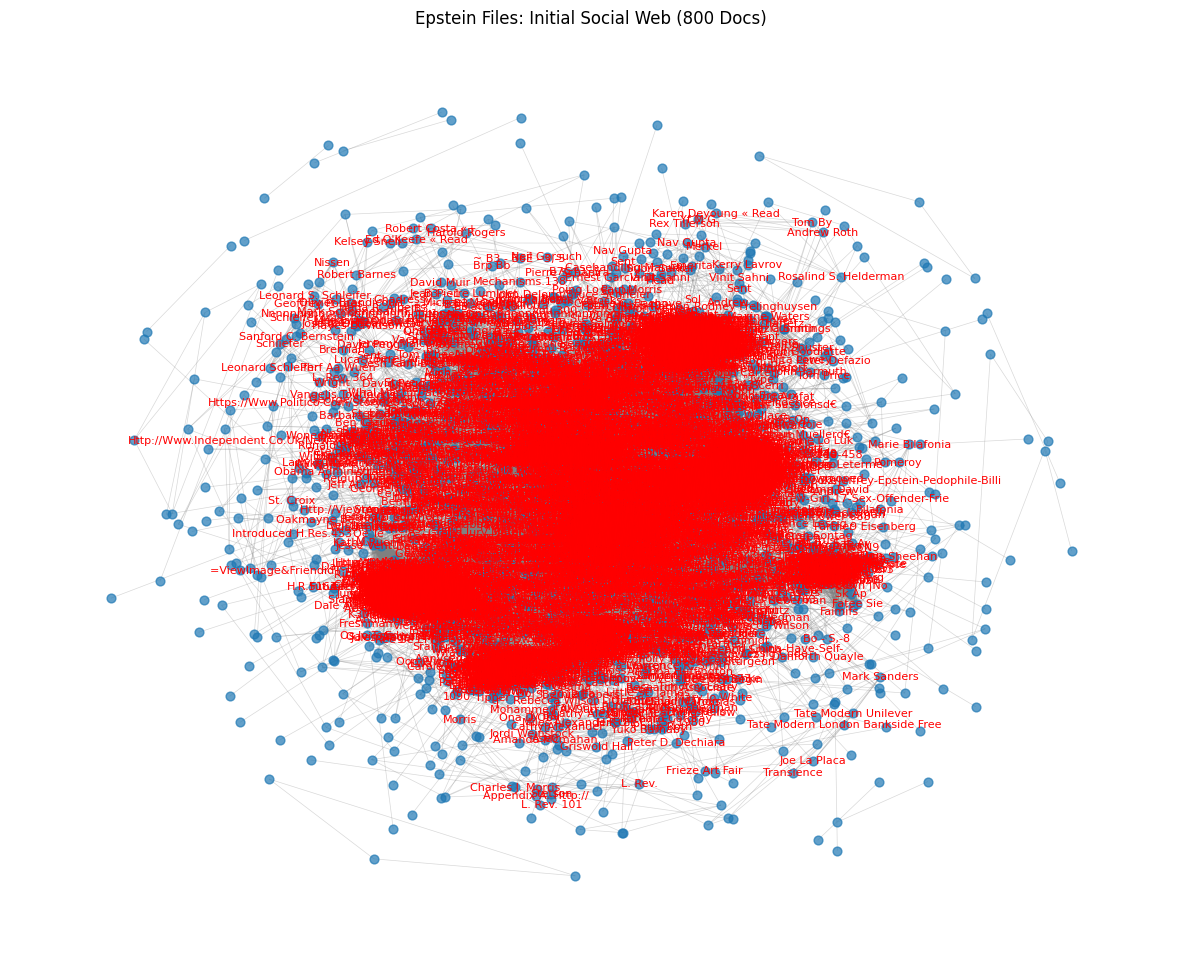

In [22]:
import matplotlib.pyplot as plt

# Create a layout (Spring layout pushes nodes apart like magnets)
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Draw the nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=40, node_color='#1f78b4', alpha=0.7)
nx.draw_networkx_edges(G, pos, width=0.5, edge_color='gray', alpha=0.3)

# Only label the "VIPs" (People with more than 5 connections)
labels = {node: node for node, degree in G.degree() if degree > 5}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='red')

plt.title("Epstein Files: Initial Social Web (800 Docs)")
plt.axis('off')
plt.show()

In [24]:
from pyvis.network import Network

# Initialize the map
# 'notebook=True' works if you are in Jupyter; otherwise, set to False
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", select_menu=True, filter_menu=True)

# Load your NetworkX graph
net.from_nx(G)

# This adds "gravity" so nodes don't overlap as much
net.toggle_physics(True)

# Save and open in your browser
net.show("epstein_interactive_network.html")

KeyboardInterrupt: 